In [1]:
# Cell 1: Authenticate with Kaggle using kagglehub
!pip install kagglehub -q
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
# Cell 2: Download the spam email dataset from Kaggle
import kagglehub

path = kagglehub.dataset_download("venky73/spam-mails-dataset")
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

100%|██████████| 1.86M/1.86M [00:00<00:00, 125MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/venky73/spam-mails-dataset/versions/1
['spam_ham_dataset.csv']


In [3]:
# Cell 3: Load the dataset into a DataFrame and preview it
import pandas as pd

df = pd.read_csv(f"{path}/spam_ham_dataset.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (5171, 4)

Columns: ['Unnamed: 0', 'label', 'text', 'label_num']

First 3 rows:


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0


In [4]:
# Cell 4: Check class distribution (spam vs ham balance)
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

label
ham     3672
spam    1499
Name: count, dtype: int64

Percentage:
label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


In [5]:
# Cell 5: Drop unused column and rename target column
df = df.drop(columns=['Unnamed: 0'])
df = df.rename(columns={'label_num': 'target'})

print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

label     0
text      0
target    0
dtype: int64

Duplicate rows: 178


In [6]:
# Cell 6: Check for missing values and duplicate rows
df = df.drop_duplicates()
print("New shape:", df.shape)

New shape: (4993, 3)


In [7]:
# Cell 7: Preprocess email text (clean, remove stopwords, lemmatize)
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'^subject:\s*', '', text, flags=re.IGNORECASE)
    text = text.lower()

    text = text.replace('\r\n', ' ').replace('\n', ' ')

    text = re.sub(r'[^a-z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head(3)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,text,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,enron methanol meter follow note gave monday p...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",hpl nom january see attached file hplnol xl hp...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",neon retreat around wonderful time year neon l...


In [8]:
# Cell 8: Split data into training and test sets
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))

Train size: 3994
Test size: 999

Train class balance:
target
0    0.707311
1    0.292689
Name: proportion, dtype: float64


In [9]:
# Cell 9: Extract features using TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (3994, 5000)
Test TF-IDF shape: (999, 5000)


In [10]:
# Cell 10: Train and compare Naive Bayes, Logistic Regression, and Linear SVM
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.982983,0.960000,0.982935,0.971332
1,Logistic Regression,0.972973,0.937500,0.972696,0.954774
0,Multinomial Naive Bayes,0.947948,0.866261,0.972696,0.916399


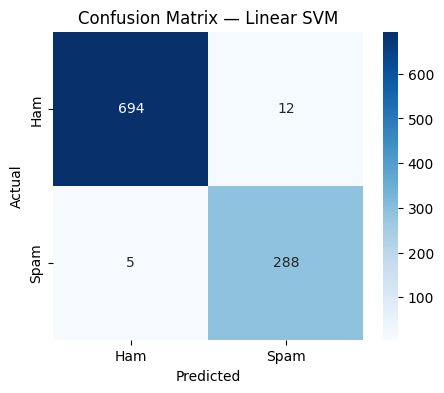

              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       706
        Spam       0.96      0.98      0.97       293

    accuracy                           0.98       999
   macro avg       0.98      0.98      0.98       999
weighted avg       0.98      0.98      0.98       999



In [11]:
# Cell 11 Evaluate the best model with confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

best_model = LinearSVC()
best_model.fit(X_train_tfidf, y_train)
preds = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Linear SVM')
plt.show()

print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))

In [12]:
# Cell 12 Test the trained model on custom example emails
def predict_email(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = best_model.predict(vec)[0]
    return "SPAM" if pred == 1 else "HAM (Not Spam)"

test_emails = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here now to claim your prize before it expires!",
    "Hi John, can we reschedule our meeting to Thursday at 3pm? Let me know if that works for you.",
    "URGENT: Your account has been suspended. Verify your identity immediately by clicking this link.",
    "Attached is the quarterly report you asked for. Let me know if you have any questions.",
]

for email in test_emails:
    result = predict_email(email)
    print(f"Email: {email[:60]}...")
    print(f"Prediction: {result}\n")

Email: Congratulations! You've won a $1000 Walmart gift card. Click...
Prediction: SPAM

Email: Hi John, can we reschedule our meeting to Thursday at 3pm? L...
Prediction: HAM (Not Spam)

Email: URGENT: Your account has been suspended. Verify your identit...
Prediction: SPAM

Email: Attached is the quarterly report you asked for. Let me know ...
Prediction: HAM (Not Spam)



In [13]:
# Cell 14: Save the trained model and vectorizer for reuse
import joblib

joblib.dump(best_model, 'spam_classifier_svm.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

from google.colab import files
files.download('spam_classifier_svm.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>